In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Binary Label data

In [21]:
binData = pd.read_csv("../dataStuff/initialData/UNSW_binData.csv")

In [22]:
binData

,rate,sttl,sload,dload,ct_srv_src,ct_state_ttl,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,ct_src_ltm,ct_srv_dst,state_CON,state_INT,label
0,0.000014,0.138393,0.000001,0.000150,0.000000,0.166667,0.02,0.00,0.000000,0.039216,0.016949,0.000000,0,0,1
1,0.000043,0.138393,0.000092,0.000364,0.019608,0.166667,0.00,0.00,0.000000,0.019608,0.000000,0.000000,0,0,1
2,0.500000,0.995536,0.119792,0.000000,0.000000,0.333333,0.00,0.00,0.000000,0.058824,0.016949,0.000000,0,1,1
3,0.000043,0.138393,0.000007,0.000869,0.039216,0.166667,0.00,0.00,0.000000,0.019608,0.000000,0.039216,0,0,1
4,0.000044,0.995536,0.000009,0.000236,0.098039,0.166667,0.00,0.00,0.000000,0.000000,0.016949,0.039216,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81168,0.166667,0.995536,0.032986,0.000000,0.862745,0.333333,0.64,0.64,0.533333,0.862745,0.542373,0.862745,0,1,0
81169,0.111111,0.995536,0.021991,0.000000,0.450980,0.333333,0.46,0.46,0.400000,0.450980,0.389831,0.450980,0,1,0
81170,0.111111,0.995536,0.021991,0.000000,0.215686,0.333333,0.04,0.04,0.066667,0.235294,0.033898,0.215686,0,1,0
81171,0.111111,0.995536,0.021991,0.000000,0.568627,0.333333,0.58,0.58,0.433333,0.568627,0.491525,0.568627,0,1,0


In [23]:
# Check basic info
binData.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81173 entries, 0 to 81172
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   rate              81173 non-null  float64
 1   sttl              81173 non-null  float64
 2   sload             81173 non-null  float64
 3   dload             81173 non-null  float64
 4   ct_srv_src        81173 non-null  float64
 5   ct_state_ttl      81173 non-null  float64
 6   ct_dst_ltm        81173 non-null  float64
 7   ct_src_dport_ltm  81173 non-null  float64
 8   ct_dst_sport_ltm  81173 non-null  float64
 9   ct_dst_src_ltm    81173 non-null  float64
 10  ct_src_ltm        81173 non-null  float64
 11  ct_srv_dst        81173 non-null  float64
 12  state_CON         81173 non-null  int64  
 13  state_INT         81173 non-null  int64  
 14  label             81173 non-null  int64  
dtypes: float64(12), int64(3)
memory usage: 9.3 MB


In [24]:
# Show summary statistics
binData.describe()

,rate,sttl,sload,dload,ct_srv_src,ct_state_ttl,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,ct_src_ltm,ct_srv_dst,state_CON,state_INT,label
count,81173.000000,81173.000000,81173.000000,81173.000000,81173.000000,81173.000000,81173.000000,81173.000000,81173.000000,81173.000000,81173.000000,81173.000000,81173.000000,81173.000000,81173.000000
mean,0.107205,0.617488,0.021459,0.010009,0.245593,0.214273,0.182131,0.166720,0.210522,0.247747,0.161676,0.244800,0.094995,0.487601,0.240080
std,0.171747,0.459551,0.035171,0.045533,0.263585,0.139817,0.199861,0.203902,0.236466,0.263667,0.169152,0.263993,0.293209,0.499849,0.427134
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000046,0.138393,0.000008,0.000000,0.000000,0.166667,0.020000,0.000000,0.000000,0.000000,0.016949,0.000000,0.000000,0.000000,0.000000
50%,0.004367,0.995536,0.001934,0.000071,0.078431,0.166667,0.100000,0.020000,0.033333,0.098039,0.101695,0.078431,0.000000,0.000000,0.000000
75%,0.125000,0.995536,0.024740,0.002063,0.490196,0.333333,0.320000,0.300000,0.500000,0.490196,0.271186,0.490196,0.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [25]:
# Count occurrences of each class (0 or 1)
binData['label'].value_counts()


label
0    61685
1    19488
Name: count, dtype: int64

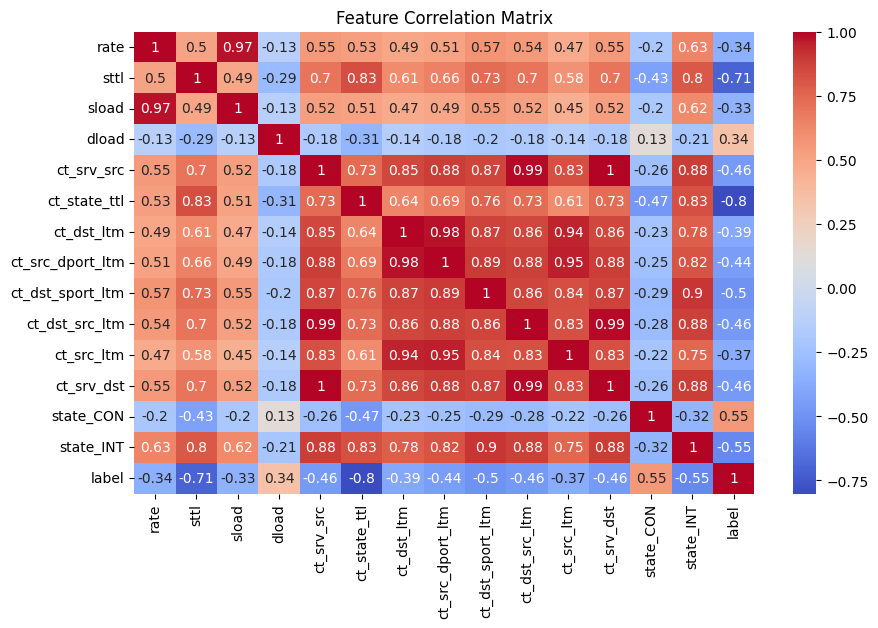

In [26]:
plt.figure(figsize=(10,6))
sns.heatmap(binData.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

In [27]:
binData['label'] = binData['label'].replace({0: "Abnormal", 1: "Normal"})

In [28]:
binData

,rate,sttl,sload,dload,ct_srv_src,ct_state_ttl,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,ct_src_ltm,ct_srv_dst,state_CON,state_INT,label
0,0.000014,0.138393,0.000001,0.000150,0.000000,0.166667,0.02,0.00,0.000000,0.039216,0.016949,0.000000,0,0,Normal
1,0.000043,0.138393,0.000092,0.000364,0.019608,0.166667,0.00,0.00,0.000000,0.019608,0.000000,0.000000,0,0,Normal
2,0.500000,0.995536,0.119792,0.000000,0.000000,0.333333,0.00,0.00,0.000000,0.058824,0.016949,0.000000,0,1,Normal
3,0.000043,0.138393,0.000007,0.000869,0.039216,0.166667,0.00,0.00,0.000000,0.019608,0.000000,0.039216,0,0,Normal
4,0.000044,0.995536,0.000009,0.000236,0.098039,0.166667,0.00,0.00,0.000000,0.000000,0.016949,0.039216,0,0,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81168,0.166667,0.995536,0.032986,0.000000,0.862745,0.333333,0.64,0.64,0.533333,0.862745,0.542373,0.862745,0,1,Abnormal
81169,0.111111,0.995536,0.021991,0.000000,0.450980,0.333333,0.46,0.46,0.400000,0.450980,0.389831,0.450980,0,1,Abnormal
81170,0.111111,0.995536,0.021991,0.000000,0.215686,0.333333,0.04,0.04,0.066667,0.235294,0.033898,0.215686,0,1,Abnormal
81171,0.111111,0.995536,0.021991,0.000000,0.568627,0.333333,0.58,0.58,0.433333,0.568627,0.491525,0.568627,0,1,Abnormal


In [29]:
binData.to_csv("../dataStuff/UNSW_binData.csv", index=False)

# MultiVarable data

In [ ]:
multiData = pd.read_csv("../dataStuff/initialData/UNSW_multiData.csv")

In [ ]:
multiData

,Unnamed: 0,dttl,swin,dwin,tcprtt,synack,ackdat,label,proto_tcp,proto_udp,service_dns,state_CON,state_FIN,attack_cat_Analysis,attack_cat_DoS,attack_cat_Exploits,attack_cat_Normal
0,3,0.992126,1.0,1.0,0.000000,0.000000,0.000000,6,1.0,0.0,0.0,0.0,1.0,0,0,0,1
1,11,0.992126,1.0,1.0,0.087972,0.103000,0.054975,6,1.0,0.0,0.0,0.0,1.0,0,0,0,1
2,15,0.000000,0.0,0.0,0.000000,0.000000,0.000000,6,0.0,1.0,0.0,0.0,0.0,0,0,0,1
3,17,0.992126,1.0,1.0,0.080709,0.115373,0.042914,6,1.0,0.0,0.0,0.0,1.0,0,0,0,1
4,21,0.992126,1.0,1.0,0.103597,0.107399,0.069747,6,1.0,0.0,0.0,0.0,1.0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81168,175335,0.000000,0.0,0.0,0.000000,0.000000,0.000000,5,0.0,1.0,1.0,0.0,0.0,0,0,0,0
81169,175336,0.000000,0.0,0.0,0.000000,0.000000,0.000000,5,0.0,1.0,1.0,0.0,0.0,0,0,0,0
81170,175338,0.000000,0.0,0.0,0.000000,0.000000,0.000000,5,0.0,1.0,1.0,0.0,0.0,0,0,0,0
81171,175339,0.000000,0.0,0.0,0.000000,0.000000,0.000000,5,0.0,1.0,1.0,0.0,0.0,0,0,0,0
